# Creating Shapefile with points

In [8]:
import geopandas as gpd
from shapely.geometry import Point

#Create a list of points with attributes
data = [
    {'name': 'Point A', 'geometry': Point(1, 1), 'description': 'First point'},
    {'name': 'Point B', 'geometry': Point(2, 2), 'description': 'Second point'},
    {'name': 'Point C', 'geometry': Point(3, 3), 'description': 'Third point'}
]

#Create a GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry='geometry')

#Save teh GeoDataFrame to a shapefile
gdf.to_file('points.shp')
print("Shapefile created successfully.")


Shapefile created successfully.


C:\Users\shrestha\AppData\Local\Temp\ipykernel_24788\2199171805.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('points.shp')
d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descriptio'
  ogr_write(


# Reading a shape file

In [9]:
gdf = gpd.read_file('points.shp')

#Display the GeoDataFrame
print('GeoDataFrame:')
print(gdf)

#Display teh geometry column
print('\nGeometry column:')
print(gdf.geometry)

#Display the CRS (Coordinate Reference System)
print("\nCRS:")
print(gdf.crs)


GeoDataFrame:
      name    descriptio     geometry
0  Point A   First point  POINT (1 1)
1  Point B  Second point  POINT (2 2)
2  Point C   Third point  POINT (3 3)

Geometry column:
0    POINT (1 1)
1    POINT (2 2)
2    POINT (3 3)
Name: geometry, dtype: geometry

CRS:
None


# Adding and Modifying Attributes

In [10]:
# Add a new column
gdf['new_attribute'] = ['New A', 'New B', 'New C']

#Modify an existing column
gdf['description'] = gdf['descriptio'].str.upper()

#display the updated GeoDataFrame
print(gdf)

# Save the updated GeoDataFrame to a new shapefile
gdf.to_file('points_update.shp')
print("Updated shapefile created successfully")

      name    descriptio     geometry new_attribute   description
0  Point A   First point  POINT (1 1)         New A   FIRST POINT
1  Point B  Second point  POINT (2 2)         New B  SECOND POINT
2  Point C   Third point  POINT (3 3)         New C   THIRD POINT
Updated shapefile created successfully


C:\Users\shrestha\AppData\Local\Temp\ipykernel_24788\2347692935.py:11: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('points_update.shp')
d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'new_attribute' to 'new_attrib'
  ogr_write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descript_1'
  ogr_write(


# Filtering Data

In [11]:
# Filter rows where name is 'Point B'
filtered_gdf = gdf[gdf['name'] == 'Point B']

print('Filtered GeoDataFrame:')
print(filtered_gdf)

Filtered GeoDataFrame:
      name    descriptio     geometry new_attribute   description
1  Point B  Second point  POINT (2 2)         New B  SECOND POINT


# Spatial Operations

In [12]:
point_a = gdf.loc[gdf['name'] == 'Point A', 'geometry'].iloc[0]
point_b = gdf.loc[gdf['name'] == 'Point B', 'geometry'].iloc[0]
print(point_a,point_b)

distance = point_a.distance(point_b)
print(f"Distance between Point A and Point B: {distance} units")

POINT (1 1) POINT (2 2)
Distance between Point A and Point B: 1.4142135623730951 units


# Visualizing the Data

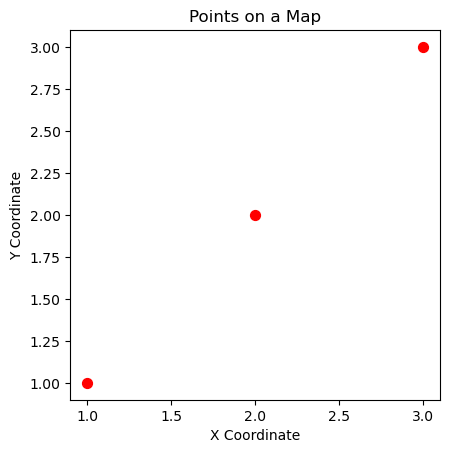

In [14]:
import matplotlib.pyplot as plt

#plot the points
gdf.plot(marker='o', color='red', markersize =50)

#show the plot
plt.title("Points on a Map")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

# Working with CRS (Coordinate Reference System)

In [15]:
# Set a CRS (e.g., WGS 84/ UTM zone 33N)
gdf.crs = "EPSG: 32633"
print(gdf.crs)

#Reproject to a different CRS (eg, WGS 84)
gdf = gdf.to_crs("EPSG: 4326")

print("Reprojected CRS:")
print(gdf.crs)

EPSG: 32633
Reprojected CRS:
EPSG: 4326


# Creating a Shapefile with lines

In [16]:
from shapely.geometry import LineString

#Create a list of lines with attributes
data = [
    {'name': 'Line 1', 'geometry': LineString([(0, 0), (1, 1)]), 'description': 'First line'},
    {'name': 'Line 2', 'geometry': LineString([(1, 1), (2, 2)]), 'description': 'Second line'}
]

# Create a geodataframe
gdf = gpd.GeoDataFrame(data, geometry='geometry')

#save the geodataframe to a shapefile
gdf.to_file('lines.shp')
print("Shapefile created successfully")

Shapefile created successfully


C:\Users\shrestha\AppData\Local\Temp\ipykernel_24788\1047744867.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('lines.shp')
d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descriptio'
  ogr_write(


# Reading and Visualizing Lines

GeoDataFrame:
     name   descriptio               geometry
0  Line 1   First line  LINESTRING (0 0, 1 1)
1  Line 2  Second line  LINESTRING (1 1, 2 2)


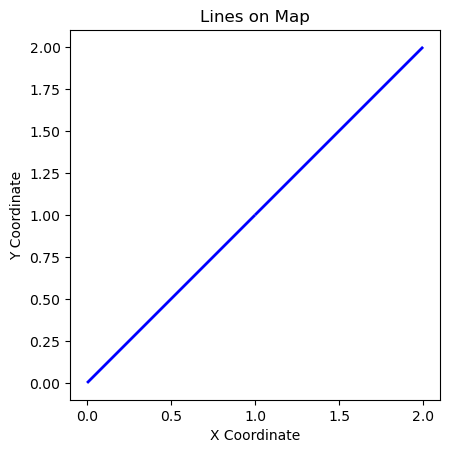

In [17]:
# Read the lines shapefile
gdf = gpd.read_file('lines.shp')

#Display the geodataframe
print("GeoDataFrame:")
print(gdf)

#plot the lines
gdf.plot(color='blue', linewidth=2)

#show the plot
plt.title('Lines on Map')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# Creating a Shapefile with Polygons

In [18]:
from shapely.geometry import Polygon

#Create a List of polygons with attributes
data = [
    {'name': 'Polygon 1', 'geometry': Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]), 'description': 'First polygon'},
    {'name': 'Polygon 2', 'geometry': Polygon([(1, 1), (2, 1), (2, 2), (1, 2)]), 'description': 'Second polygon'}
]

#Create a geodataframe
gdf = gpd.GeoDataFrame(data, geometry='geometry')

#save teh geodataframe to a shapefile
gdf.to_file("polygons.shp")
print("Shapefile created successfully")

Shapefile created successfully


C:\Users\shrestha\AppData\Local\Temp\ipykernel_24788\1921872213.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file("polygons.shp")
d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descriptio'
  ogr_write(


# Reading and Visualizing polygons

GeoDataFrame:
        name      descriptio                             geometry
0  Polygon 1   First polygon  POLYGON ((0 0, 0 1, 1 1, 1 0, 0 0))
1  Polygon 2  Second polygon  POLYGON ((1 1, 1 2, 2 2, 2 1, 1 1))


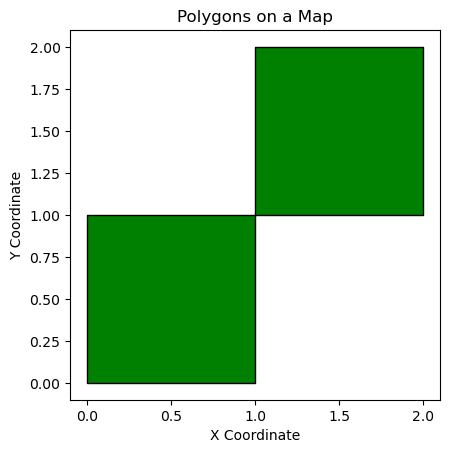

In [19]:
gdf = gpd.read_file('polygons.shp')

#Display the GeoDataframe
print("GeoDataFrame:")
print(gdf)

#plot the polygons
gdf.plot(color='green', edgecolor='black')

#show the plot
plt.title("Polygons on a Map")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()